<h1 style="color:red;">Numerical Simulation Laboratory - Exercise 10</h1>

The aim of this exercise is to extend the Genetic Algorithm developed in the previous exercise by implementing a **Parallel Tempering** algorithm for the Traveling Salesman Problem (TSP). Parallel Tempering is a Monte Carlo technique designed to improve the exploration of complex optimization landscapes by simultaneously considering several replicas of the system at different temperatures.

The different replicas are parallelized using the **MPI** library. The lowest-temperature replica is expected to provide the best candidate solution, since it is associated with the strongest preference for configurations with lower cost.

The method is finally applied to a TSP consisting of the $110$ Italian provincial capitals, using their longitude and latitude coordinates provided in the `cap_prov_ita.dat` file. The resulting performance is then compared with that of the non-parallel Genetic Algorithm developed in the previous exercise, in order to assess whether the use of multiple temperatures and parallel exploration leads to an improvement in the quality of the solution.

## Parallel Computing and MPI

The Parallel Tempering algorithm naturally lends itself to a **parallel computing** implementation, since several replicas of the same system are simulated simultaneously at different temperatures. In this work, distributed-memory parallelism is implemented using the **Message Passing Interface (MPI)** library. Each process is identified by a unique rank and is associated with a single replica of the system.

The different MPI processes perform their own Monte Carlo simulations independently, with each replica evolving at a specific temperature. The temperature associated with each rank is determined by distributing the temperatures between a minimum and a maximum value. In this way, low-temperature replicas focus more strongly on low-energy configurations, while high-temperature replicas provide greater exploration of the solution space.

Although the replicas evolve independently between exchanges, communication between processes is periodically required to implement the **replica-exchange mechanism**. In the present implementation, an exchange is attempted between adjacent temperatures every $10$ Monte Carlo steps. MPI communication is used to exchange the relevant information between the two neighbouring processes, including the current path, and its cost.

The acceptance of the exchange is evaluated using the Metropolis criterion introduced in the previous section. To avoid conflicts when multiple neighbouring pairs are considered simultaneously, the exchanges are organized according to an **alternating even--odd scheme**. During one exchange phase, pairs such as $(0,1)$, $(2,3)$, and so on are considered, while during the following phase the pairs are shifted to $(1,2)$, $(3,4)$, and so on. This allows each process to participate in at most one exchange during a given phase.

The communication between neighbouring processes is handled through MPI. In particular, $\texttt{MPI\_Sendrecv}$ is used to exchange the configurations, costs, and temperatures of the two replicas, while $\texttt{MPI\_Send}$ and $\texttt{MPI\_Recv}$ are used to communicate the result of the acceptance test and, when necessary, the exchanged configuration.

At the end of the simulation, the best cost and corresponding path found by each process are collected using $\texttt{MPI\_Gather}$.

The parallel implementation therefore allows the different temperature replicas to evolve concurrently while providing the communication mechanism required for their periodic exchange. This combination of **independent exploration** and **inter-process communication** is the key feature that allows Parallel Tempering to exploit parallel computing effectively.

## Parallel Tempering

The **Parallel Tempering** algorithm is a Monte Carlo-based optimization and sampling technique designed to improve the exploration of complex energy landscapes. Unlike **Simulated Annealing**, where a single system is progressively cooled according to a temperature schedule, Parallel Tempering considers $N_T$ different systems, or replicas, which are simulated simultaneously at different temperatures.

The replicas at higher temperatures have a greater ability to explore the parameter space, since the larger thermal fluctuations make it easier to escape from local minima. Conversely, the replicas at lower temperatures are more strongly concentrated around low-energy configurations and therefore provide a stronger **intensification** of the search in promising regions. The algorithm thus combines the two main components of a metaheuristic strategy: **diversification**, promoted by the high-temperature replicas, and **intensification**, promoted by the low-temperature replicas.

A problem arises from the fact that low-temperature replicas can become trapped in a local minimum and lose their ability to explore other regions of the parameter space. To overcome this limitation, Parallel Tempering introduces additional Monte Carlo trial moves in which two replicas at different temperatures are proposed for exchange. In this way, a configuration explored by a high-temperature replica can be transferred to a lower-temperature replica, allowing the latter to benefit from the greater exploratory capability of the higher temperature.

Consider two replicas $i$ and $j$, with inverse temperatures $\beta_i$ and $\beta_j$ and configurations $x_i$ and $x_j$. The probability of accepting an exchange between the two replicas is given by

$$
P_{\mathrm{swap}}
=\min
\left(
1,
e^{(\beta_j-\beta_i)[L(x_i)-L(x_j)]}
\right),
$$

where $L(x)$ represents the energy, or cost function, associated with configuration $x$.

The exchange mechanism allow configurations to move through the temperature ladder. A configuration can therefore explore the energy landscape at high temperature, where barriers are easier to overcome, and subsequently reach lower temperatures, where configurations with lower energy are preferentially sampled.

In the context of optimization, the lowest-temperature replica is expected to provide a strong intensification of the search around low-energy configurations. Consequently, it often provides the best candidate solution among the replicas, although the algorithm does not guarantee that this configuration corresponds to the global minimum. The exchange mechanism is particularly useful because it allows low-temperature replicas to periodically receive configurations that have been explored at higher temperatures, reducing the risk of remaining permanently trapped in a single local minimum.

## Implementation of Parallel Tempering

The Parallel Tempering algorithm was implemented by extending the existing `TSP` class and introducing a dedicated MPI exchange function. The main functions added for this exercise are contained in `TSP.cpp`, while the MPI-specific exchange mechanism is implemented in `Exchange.cpp`. Two auxiliary functions are also used for the initialization of the simulation: `SetRandom`, implemented before `main`, and `read_cities`, implemented in `Cities.cpp`.

### Auxiliary functions

The function `SetRandom` initializes the random number generator associated with each MPI process. The four components of the seed are then modified according to the MPI rank before initializing the `Random` object. This ensures that different processes use different random-number sequences while maintaining a reproducible initialization.

The function `read_cities` reads the coordinates of the cities from the input file and stores them as two-dimensional vectors. The number of cities to be read is specified by the parameter $N$. The resulting vector of coordinates is then used to initialize the `TSP` object.

### Functions implemented in `TSP.cpp`

The function `initialize_replica` creates and initializes a replica of the system. A temperature is assigned to the replica, a random path is generated, and its corresponding cost is calculated. Each MPI process therefore starts with an independently generated configuration at its assigned temperature.

The function `trial_move` generates a trial configuration starting from the current path. Four mutation operators are available, and one of them is selected with equal probability. 

The function `metropolis_step` performs a complete Metropolis update for a replica. A trial move is first generated and the difference in cost between the trial and current configurations is calculated. The trial configuration is then accepted according to the Metropolis probability

$$
P_{\mathrm{acc}}=
\min\left(1,e^{-\Delta L/T}\right),
$$

where $\Delta L$ is the variation of the cost function and $T$ is the temperature associated with the replica.

The function `exchange` implements the acceptance criterion for an exchange between two replicas. The temperatures and costs of the two replicas are used to calculate the exchange probability

$$
P_{\mathrm{swap}}=
\min
\left(
1,
e^{(\beta_1-\beta_2)(L_1-L_2)}
\right),
$$

where $\beta_i=1/T_i$. If the exchange is accepted, the paths of the two replicas are swapped, while their temperatures remain unchanged. In this way, configurations can move between different temperatures while each MPI process retains its position in the temperature ladder.

### MPI exchange in `Exchange.cpp`

The function `exchange_mpi` connects the replica-exchange mechanism with the MPI parallel implementation. Two neighbouring MPI processes first exchange their current paths and costs using `MPI_Sendrecv`. This information allows the exchange probability to be evaluated using the `exchange` function implemented in `TSP.cpp`.

To avoid having both processes independently evaluate the same exchange, the process with the lower rank performs the acceptance test. The resulting decision is then communicated to the partner process using `MPI_Send` and `MPI_Recv`. If the exchange is accepted, the updated path and cost are transmitted to the corresponding process.

The temperatures are not exchanged between processes: they remain associated with their respective MPI ranks. Only the configurations are exchanged, allowing a path to move from a high-temperature replica to a low-temperature replica and vice versa.

### Main simulation and final collection

The `main` function initializes the MPI environment and assigns one replica to each MPI process. The temperatures are distributed geometrically between $T_{\min}$ and $T_{\max}$ according to the rank,

$$
T_i=
T_{\min}
\left(
\frac{T_{\max}}{T_{\min}}
\right)^{\frac{i}{N_T-1}},
$$

where $i$ is the MPI rank and $N_T$ is the total number of processes.

Each replica performs a Metropolis step independently. Every $10$ Monte Carlo steps, an exchange with a neighbouring replica is attempted according to the alternating even--odd scheme. The current cost and the progressive best cost are stored during the simulation, while the best configuration found by each rank is updated whenever a lower-cost path is encountered.

At the end of the simulation, `MPI_Gather` is used to collect the best cost and corresponding path from all MPI processes.

### Initial parameters

The Parallel Tempering simulation was performed using $N=110$ cities and a total of $n=100000$ Metropolis steps. Replica exchanges were attempted every $10$ Metropolis steps. The temperature range was chosen between $T_{\min}=0.1$ and $T_{\max}=0.8$, with $10$ MPI ranks corresponding to the $10$ replicas of the system.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

In [2]:
n_ranks = 10
T_min = 0.1
T_max = 0.8
temperatures = [T_min * (T_max / T_min) ** (rank / (n_ranks - 1)) for rank in range(n_ranks)] 

In [3]:
# Load map
url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"

world = gpd.read_file(url)

italy = world[world["ADMIN"] == "Italy"]

In [4]:
cost_prefix = "Esercizio 2/PT_rank_"
path_prefix = "Esercizio 2/PT_best_path_rank_"

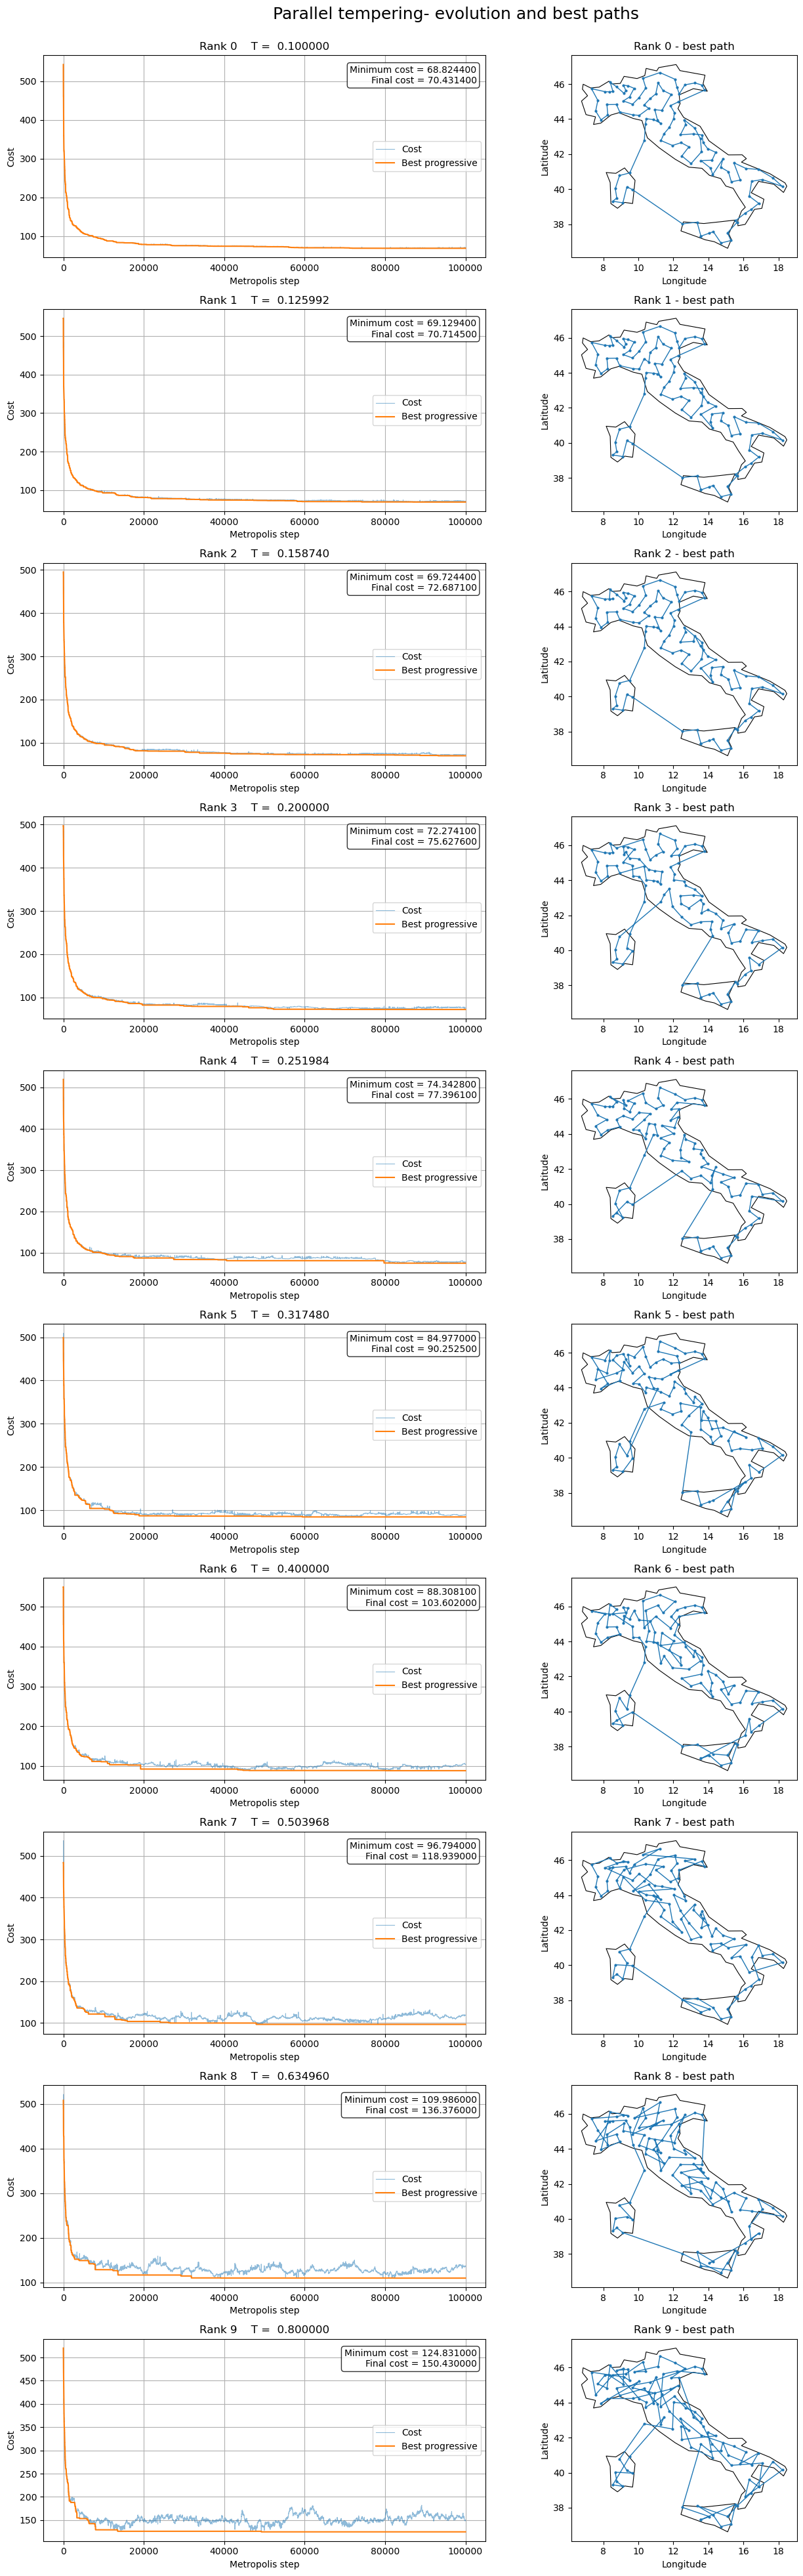

In [5]:
fig, axes = plt.subplots(n_ranks, 2, figsize=(14, 4 * n_ranks))

for rank in range(n_ranks):

    ax_cost = axes[rank, 0]
    ax_path = axes[rank, 1]
    T = temperatures[rank]

    cost_file = f"{cost_prefix}{rank}.dat"

    data = np.loadtxt(cost_file)

    generation = data[:, 0]
    cost = data[:, 1]
    best_prog = data[:, 2]

    min_cost = np.min(cost)
    final_cost = cost[-1]

    ax_cost.plot(generation, cost, linewidth=0.8, alpha=0.5, label="Cost")
    ax_cost.plot(generation, best_prog, linewidth=1.5, label="Best progressive")
    
    ax_cost.set_title(f"Rank {rank}    T = {T : 4f}")
    ax_cost.set_xlabel("Metropolis step")
    ax_cost.set_ylabel("Cost")
    ax_cost.grid(True)
    ax_cost.legend()

    ax_cost.text(
        0.98, 0.95,
        f"Minimum cost = {min_cost:.6f}\nFinal cost = {final_cost:.6f}",
        transform=ax_cost.transAxes,
        ha="right",
        va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

    path_file = f"{path_prefix}{rank}.dat"

    path = np.loadtxt(path_file)

    longitude = path[:, 0]
    latitude = path[:, 1]

    italy.plot(ax=ax_path, facecolor="none", edgecolor="black", linewidth=0.8)
    
    ax_path.plot(longitude, latitude, marker = "o", markersize = 2, linewidth = 1.0)
    
    ax_path.set_title(f"Rank {rank} - best path")
    ax_path.set_xlabel("Longitude")
    ax_path.set_ylabel("Latitude")
    ax_path.set_aspect("equal")

fig.suptitle("Parallel tempering- evolution and best paths", fontsize = 18)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


**Figure 1.** Evolution of the cost function and progressive best cost for the $10$ replicas at different temperatures. The lower-temperature replicas exhibit lower costs and a less fluctuating trajectory, reflecting the stronger tendency toward intensification around low-cost configurations. Conversely, the higher-temperature replicas show larger costs and a more irregular evolution due to the greater thermal fluctuations and exploratory capability. The lowest cost obtained was $68.8244$ for the replica at $T=0.1$, while the replica at $T=0.8$ reached a minimum cost of $124.8310$.

In [6]:
cost_file_GA = "Esercizio 2/Best_cost_GA.dat"
path_file_GA = "Esercizio 2/Best_path_GA.dat"

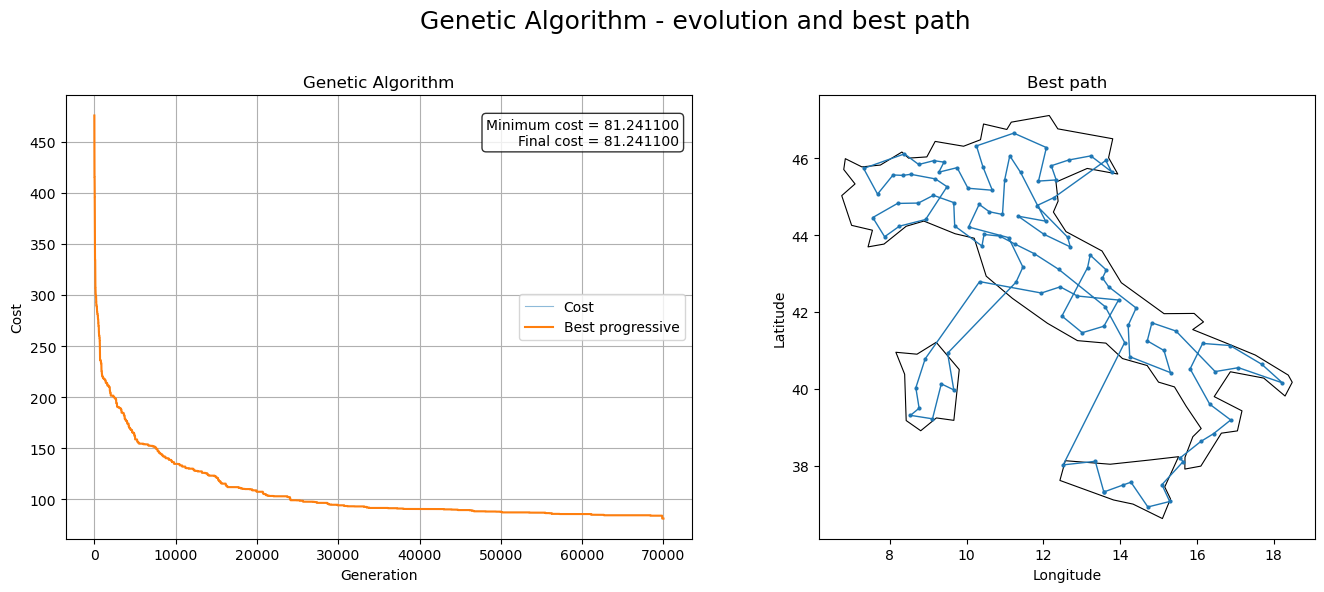

In [8]:
data = np.loadtxt(cost_file_GA)

generation = data[:, 0]
cost = data[:, 1]
best_prog = data[:, 2]
best_half = data[:, 3]

min_cost = np.min(cost)
final_cost = cost[-1]

path = np.loadtxt(path_file_GA)

longitude = path[:, 0]
latitude = path[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax_cost = axes[0]
ax_path = axes[1]

ax_cost.plot(generation, cost, linewidth=0.8, alpha=0.5, label="Cost")
ax_cost.plot(generation, best_prog, linewidth=1.5, label="Best progressive")

ax_cost.set_title("Genetic Algorithm")
ax_cost.set_xlabel("Generation")
ax_cost.set_ylabel("Cost")
ax_cost.grid(True)
ax_cost.legend()

ax_cost.text(
        0.98, 0.95,
        f"Minimum cost = {min_cost:.6f}\nFinal cost = {final_cost:.6f}",
        transform=ax_cost.transAxes,
        ha="right",
        va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

italy.plot(
    ax=ax_path,
    facecolor="none",
    edgecolor="black",
    linewidth=0.8
)

ax_path.plot(
    longitude,
    latitude,
    marker="o",
    markersize=2,
    linewidth=1.0
)

ax_path.set_title("Best path")
ax_path.set_xlabel("Longitude")
ax_path.set_ylabel("Latitude")
ax_path.set_aspect("equal")

fig.suptitle(
    "Genetic Algorithm - evolution and best path",
    fontsize=18
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Figure 2.** Evolution of the cost function and progressive best cost for the Genetic Algorithm applied to the same TSP problem without Parallel Tempering. The simulation was performed with a population of $M=10$ individuals for $70000$ generations, using one elite individual and a crossover probability of $p_{\mathrm{crossover}}=0.6$, with the four mutation operators selected with probability $0.05$ each. The best cost obtained was $81.2411$. This value is higher than the best cost found by the lowest-temperature replica in the Parallel Tempering simulation, $68.8244$, while being comparable to the costs reached by the intermediate-temperature replicas.

## Conclusions

The comparison between the Genetic Algorithm and Parallel Tempering shows that both methods are able to effectively explore the solution space of the TSP problem. The Parallel Tempering simulation achieved a lower best cost of $68.8244$, compared with $81.2411$ obtained by the Genetic Algorithm. The different temperature replicas also illustrate the balance between exploration and intensification: higher temperatures allow larger fluctuations and broader exploration, while lower temperatures favour the refinement of low-cost configurations. Overall, the results highlight the ability of Parallel Tempering to combine these two aspects through the exchange of configurations between replicas.